In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import shap

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

ROOT = Path.cwd().parents[1]
print(ROOT)

DATA_PROCESSED = ROOT/"data/processed"

/workspaces/BoxOffice-Oracle/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/workspaces/BoxOffice-Oracle


In [2]:
model_df = pd.read_csv(
    DATA_PROCESSED/"00_descr_title_df.csv"
)

print(model_df.shape)
model_df.head()

(1606, 35)


,tconst,primaryTitle,startYear,the_numbers_url,scrape_success,scrape_error,opening_weekend_gross,opening_theaters,domestic_release_date,release_type,...,legs,plot_point,raw_opening_weekend_text,raw_theater_counts_text,raw_domestic_releases_text,plot_summary,title_plot_similarity,franchise,title_word_count,title_char_count
0,tt0120667,Fantastic Four,2005.0,https://www.the-numbers.com/movie/Fantastic-Fo...,True,NaN,56061504.0,3602.0,2005-07-08,Wide,...,2.76,"Friends turned Enemies, Origin Story, Revenge","$56,061,504 (36.2% of total gross)","3,602 opening theaters/3,619 max. theaters, 5....","July 8th, 2005 (Wide) by 20th Century Fox",Scientist Reed Richards persuades his arrogant...,0.217350,Fantastic Four,2,14
1,tt0121766,Star Wars: Episode III - Revenge of the Sith,2005.0,https://www.the-numbers.com/movie/Star-Wars-Ep...,True,NaN,108435841.0,3661.0,2005-05-19,Wide,...,3.82,"Betrayal, Cloning, Cyborg, Death of a Spouse o...","$108,435,841 (26.2% of total gross)","3,661 opening theaters/3,663 max. theaters, 8....","May 19th, 2005 (Wide) by 20th Century Fox Apri...","Years after the onset of the Clone Wars, the n...",0.473704,Star Wars,9,44
2,tt0200465,The Bank Job,2008.0,https://www.the-numbers.com/movie/Bank-Job-The,True,NaN,5935256.0,1603.0,2008-03-07,Wide,...,5.06,"Bank Robbery, Blackmail, Corrupt Cops, Heist, ...","$5,935,256 (19.7% of total gross)","1,603 opening theaters/1,613 max. theaters, 6....","March 7th, 2008 (Wide) by Lionsgate",Self-reformed petty criminal Terry Leather has...,0.257783,NaN,3,12
3,tt0204313,Exorcist: The Beginning,2004.0,https://www.the-numbers.com/movie/Exorcist-The...,True,NaN,18054001.0,2803.0,2004-08-20,Wide,...,2.32,"Demons, Possessed","$18,054,001 (43.2% of total gross)","2,803 opening theaters/2,813 max. theaters, 4....","August 20th, 2004 (Wide) by Warner Bros.",Father Lankester Merrin lost his faith after t...,0.143046,Exorcist,3,23
4,tt0257516,Cursed,2005.0,https://www.the-numbers.com/movie/Cursed,True,NaN,9633085.0,2805.0,2005-02-25,Wide,...,2.00,Werewolf,"$9,633,085 (49.9% of total gross)","2,805 opening theaters/2,805 max. theaters, 3....","February 25th, 2005 (Wide) by Miramax/Dimension","In Los Angeles, siblings Ellie and Jimmy come ...",0.248333,NaN,1,6


In [3]:
model_df.columns

Index(['tconst', 'primaryTitle', 'startYear', 'the_numbers_url',
       'scrape_success', 'scrape_error', 'opening_weekend_gross',
       'opening_theaters', 'domestic_release_date', 'release_type',
       'all_domestic_release_types', 'distributor', 'production_budget',
       'MPA_rating', 'MPA_rating_reason', 'runtime_minutes', 'genre',
       'subgenre', 'target_audience', 'time_period_setting', 'source',
       'production_method', 'creative_type', 'production_countries',
       'languages', 'legs', 'plot_point', 'raw_opening_weekend_text',
       'raw_theater_counts_text', 'raw_domestic_releases_text', 'plot_summary',
       'title_plot_similarity', 'franchise', 'title_word_count',
       'title_char_count'],
      dtype='str')

In [7]:
model_df["domestic_release_date"] = pd.to_datetime(
    model_df["domestic_release_date"],
    errors="coerce"
)

model_df["release_month"] = (
    model_df["domestic_release_date"]
    .dt.month
)

model_df["release_day_of_year"] = (
    model_df["domestic_release_date"]
    .dt.dayofyear
)

In [24]:
model_df["log_opening_weekend_gross"] = np.log1p(model_df["opening_weekend_gross"])


In [25]:
model_df = model_df[
    model_df["franchise"].isna() |
    (model_df["franchise"].astype(str).str.strip() == "")
].copy()

In [65]:
target = "log_opening_weekend_gross"

num_group_features = [
    "title_plot_similarity",
    # "title_word_count",
    # "title_char_count",
]

numeric_features = [
    # "opening_theaters",
    "production_budget",
    "runtime_minutes",
    "release_month",
    "release_day_of_year",
]

people_features = [
]

cat_group_feature = [

]

categorical_features = [
    # "release_type",
    "distributor",
    "MPA_rating",
    "genre",
    "subgenre",
    "source",
    "production_method",
    "creative_type",
    "production_countries",
    "languages",
    # "franchise",
 ] + people_features + cat_group_feature

In [66]:
feature_cols = numeric_features + categorical_features

model_data = model_df[
    feature_cols + [target, "opening_weekend_gross"]
].copy()

X = model_data[feature_cols]
y = model_data[target]

print(X.shape)
print(y.shape)

(1025, 13)
(1025,)


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [68]:
y_test_dollars = np.expm1(y_test)

In [69]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [70]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, pred_log)
    mae_log = mean_absolute_error(y_test, pred_log)

    pred_dollars = np.expm1(pred_log)

    mae_dollars = mean_absolute_error(y_test_dollars, pred_dollars)

    results = {
        "model": name,
        "r2_log": r2_log,
        "mae_log": mae_log,
        "mae_dollars": mae_dollars
    }

    return results, pred_log, pred_dollars

In [71]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_results, ridge_pred_log, ridge_pred_dollars = evaluate_model(
    "Ridge Baseline",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

ridge_results

{'model': 'Ridge Baseline',
 'r2_log': 0.3654823209667494,
 'mae_log': 0.9632537855686834,
 'mae_dollars': 8421581.87900773}

In [72]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_results, xgb_pred_log, xgb_pred_dollars = evaluate_model(
    "XGBoost Baseline",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_results

{'model': 'XGBoost Baseline',
 'r2_log': 0.5195033905929445,
 'mae_log': 0.7939568571659096,
 'mae_dollars': 5551707.587652439}

In [63]:
results_df = pd.DataFrame([
    ridge_results,
    xgb_results
])

results_df

,model,r2_log,mae_log,mae_dollars
0,Ridge Baseline,0.367035,0.962311,8.420707e+06
1,XGBoost Baseline,0.525233,0.783019,5.371647e+06


In [64]:
plot_df = pd.DataFrame({
    "actual": y_test_dollars,
    "predicted": xgb_pred_dollars
})

fig = px.scatter(
    plot_df,
    x="actual",
    y="predicted",
    title="XGBoost Baseline: Actual vs Predicted",
    opacity=0.6
)

fig.add_shape(
    type="line",
    x0=plot_df["actual"].min(),
    y0=plot_df["actual"].min(),
    x1=plot_df["actual"].max(),
    y1=plot_df["actual"].max(),
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
X_train_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_train)
)

X_test_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_test)
)

feature_names = (
    xgb_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

trained_xgb = xgb_model.named_steps["model"]

c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['g9_dynamic_franchise_emb_0' 'g9_dynamic_franchise_emb_1'
 'g9_dynamic_franchise_emb_2' 'g9_dynamic_franchise_emb_3'
 'g9_dynamic_franchise_emb_4' 'g9_dynamic_franchise_emb_5'
 'g9_dynamic_franchise_emb_6' 'g9_dynamic_franchise_emb_7'
 'g9_dynamic_franchise_emb_8' 'g9_dynamic_franchise_emb_9'
 'g9_dynamic_franchise_emb_10' 'g9_dynamic_franchise_emb_11'
 'g9_dynamic_franchise_emb_12' 'g9_dynamic_franchise_emb_13'
 'g9_dynamic_franchise_emb_14' 'g9_dynamic_franchise_emb_15'
 'g9_dynamic_franchise_emb_16' 'g9_dynamic_franchise_emb_17'
 'g9_dynamic_franchise_emb_18' 'g9_dynamic_franchise_emb_19'
 'g9_dynamic_franchise_emb_20' 'g9_dynamic_franchise_emb_21'
 'g9_dynamic_franchise_emb_22' 'g9_dynamic_franchise_emb_23'
 'g9_dynamic_franchise_emb_24']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\User

In [53]:
explainer = shap.TreeExplainer(trained_xgb)

X_shap = X_test_transformed[:500]

shap_values = explainer.shap_values(X_shap)

NameError: name 'trained_xgb' is not defined

In [54]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

NameError: name 'shap_values' is not defined

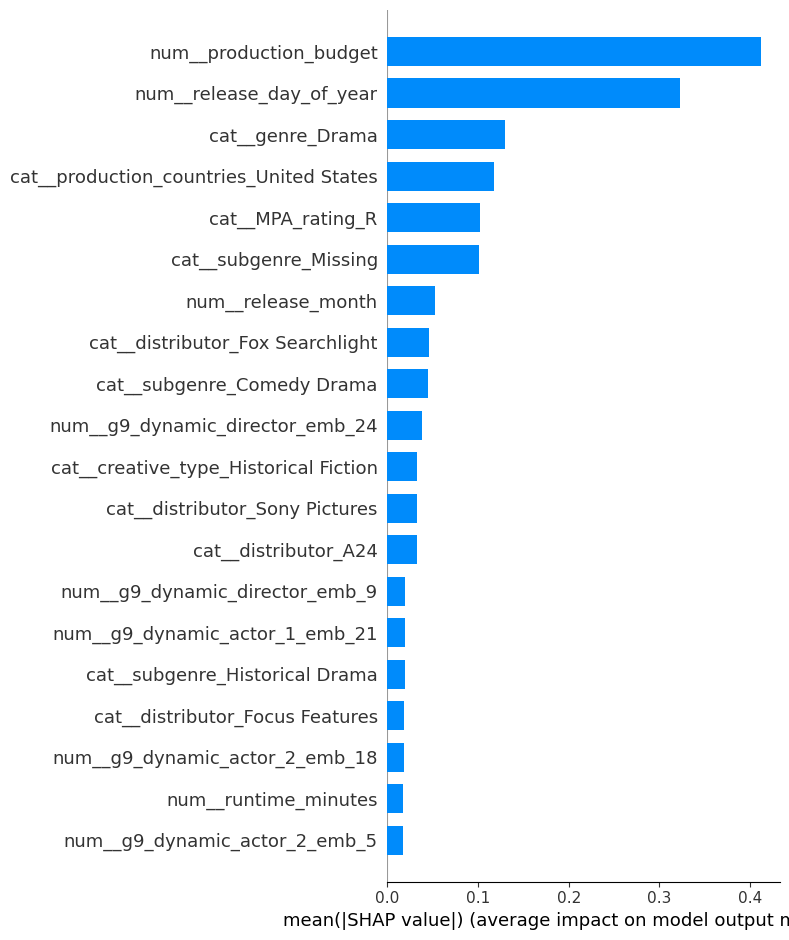

In [139]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)

In [140]:
error_df = X_test.copy()

error_df["actual_log"] = y_test
error_df["pred_log"] = xgb_pred_log

error_df["actual_opening_weekend"] = np.expm1(y_test)
error_df["pred_opening_weekend"] = xgb_pred_dollars

error_df["abs_error"] = (
    error_df["actual_opening_weekend"] -
    error_df["pred_opening_weekend"]
).abs()

error_df.sort_values("abs_error", ascending=False).head(20)

,production_budget,runtime_minutes,release_month,release_day_of_year,g9_dynamic_director_emb_0,g9_dynamic_director_emb_1,g9_dynamic_director_emb_2,g9_dynamic_director_emb_3,g9_dynamic_director_emb_4,g9_dynamic_director_emb_5,...,director_id,writer_id,actor_1,actor_2,actor_3,actual_log,pred_log,actual_opening_weekend,pred_opening_weekend,abs_error
39,25000000.0,127.0,2,56,NaN,NaN,NaN,NaN,NaN,NaN,...,nm0000154,nm0280179,nm0001029,nm0000899,nm0411581,18.244517,15.676565,83848082.0,6430514.00,77417568.00
1393,95000000.0,105.0,3,72,NaN,NaN,NaN,NaN,NaN,NaN,...,nm7633075,nm7633074,nm11673205,nm7633076,nm8063245,18.033213,16.651020,67877361.0,17039080.00,50838281.00
77,125000000.0,123.0,5,149,NaN,NaN,NaN,NaN,NaN,NaN,...,nm0000386,nm0000386,nm0000598,nm0350453,nm0002536,18.045894,16.879282,68743584.0,21408144.00,47335440.00
742,175000000.0,89.0,5,149,NaN,NaN,NaN,NaN,NaN,NaN,...,nm0230032,nm0677037,nm0000799,nm2973712,nm0001652,18.036617,17.114613,68108790.0,27088304.00,41020486.00
1795,55000000.0,134.0,11,306,-0.201306,-0.189365,0.021810,-0.155712,-0.051303,0.074133,...,nm0001741,nm0565026,nm1785339,nm2377903,nm3152605,17.748534,16.423246,51061119.0,13568294.00,37492825.00
990,200000000.0,113.0,6,168,-0.131304,0.174711,-0.155049,-0.087764,-0.027101,0.000303,...,nm0132709,nm0075528,nm0005351,nm0515116,nm0765597,17.789086,16.931713,53174303.0,22560544.00,30613759.00
71,170000000.0,132.0,5,128,NaN,NaN,NaN,NaN,NaN,NaN,...,nm0814085,nm0814085,nm0413168,nm0000295,nm0746896,17.761897,16.880322,51748040.0,21430408.00,30317632.00
441,NaN,103.0,2,40,0.122064,0.000302,0.173804,-0.019438,-0.017921,-0.098621,...,nm0005367,nm0000552,nm0000552,nm0628601,nm0187719,17.347603,15.694255,34195434.0,6545280.00,27650154.00
340,52000000.0,106.0,6,153,NaN,NaN,NaN,NaN,NaN,NaN,...,nm0715636,nm1275670,nm0000098,nm0000681,nm0269463,17.483493,16.459318,39172785.0,14066661.00,25106124.00
95,105000000.0,115.0,7,198,NaN,NaN,NaN,NaN,NaN,NaN,...,nm0001639,nm0899113,nm0000226,nm0005256,nm0339304,17.770208,17.160500,52179887.0,28360264.00,23819623.00


In [141]:
results_df.to_csv(
    DATA_PROCESSED/"feature_testing/results/g9_model_results.csv",
    index=False
)

error_df.to_csv(
    DATA_PROCESSED/"feature_testing/errors/g9_xgb_test_errors.csv",
    index=False
)